### Import Libraries

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from scipy.stats import linregress

#### Data Loading & Date Parsing

In [98]:
df = pd.read_csv("../data/tanzania.csv")
print(df.shape)
display(df.head())

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


Add Country column

In [99]:
df["Country"] = "Tanzania"

viewing the top rows of the data after adding country column

In [100]:
display(df.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


Viewing the bottom rows of the dataset

In [101]:
display(df.tail())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania
4107,2026,90,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56,Tanzania


In [102]:
# added Country column
print(df.shape)
print(df.columns.tolist())

(4108, 13)
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


##### Convert YEAR and DOY to a single Datetime column

In [103]:
# 3. Convert YEAR and DOY to a single Datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month for seasonal analysis
df["Month"] = df["Date"].dt.month

# 5. Set Date as the index
df.set_index("Date", inplace=True)

# Final check of the data structure
print(df.shape)
print(f"Dataset columns: {df.columns.tolist()}")
df.head()

(4108, 14)
Dataset columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1


Drop redundant columns after changing to datetime

In [104]:
df.drop(columns=["YEAR", "DOY"], inplace=True)

# Final check to see the clean dataset
print("Redundant columns removed.")
df.head()

Redundant columns removed.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1


In [105]:
print(df.index)

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[us]', name='Date', length=4108, freq=None)


In [106]:
display(df.loc['2015-01-01'])

T2M               27.56
T2M_MAX           29.52
T2M_MIN           26.22
T2M_RANGE           3.3
PRECTOTCORR        7.24
RH2M              80.97
WS2M               4.68
WS2M_MAX           6.01
PS               100.52
QV2M              18.61
Country        Tanzania
Month                 1
Name: 2015-01-01 00:00:00, dtype: object

### Summary Statistics & Missing-Value Report

In [107]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
DatetimeIndex: 4108 entries, 2015-01-01 to 2026-03-31
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T2M          4108 non-null   float64
 1   T2M_MAX      4108 non-null   float64
 2   T2M_MIN      4108 non-null   float64
 3   T2M_RANGE    4108 non-null   float64
 4   PRECTOTCORR  4108 non-null   float64
 5   RH2M         4108 non-null   float64
 6   WS2M         4108 non-null   float64
 7   WS2M_MAX     4108 non-null   float64
 8   PS           4108 non-null   float64
 9   QV2M         4108 non-null   float64
 10  Country      4108 non-null   str    
 11  Month        4108 non-null   int32  
dtypes: float64(10), int32(1), str(1)
memory usage: 562.8 KB
None


A. Handling NASA Sentinel Values (-999) 

In [108]:
# Create a count of how many -999 values exist in each column
sentinel_counts = (df == -999).sum()

# Filter to show only columns that actually have -999 values
sentinel_counts = sentinel_counts[sentinel_counts > 0]

print("--- NASA Sentinel Value (-999) Report ---")
if not sentinel_counts.empty:
    print(sentinel_counts)
else:
    print("No -999 values found in the dataset.")

df.replace(-999, np.nan, inplace=True)

--- NASA Sentinel Value (-999) Report ---
No -999 values found in the dataset.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,3
2026-03-28,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,3
2026-03-29,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,3


B. Duplicate Check

In [109]:
duplicates_count = df.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicates_count}")

# If duplicates exist, we drop them
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped successfully.")

Total Duplicate Rows Found: 0


C. Statistical Profiling
- Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [110]:
# Generate descriptive statistics for all numeric columns
print("summary statistics")
display(df.describe())

summary statistics


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,6.423564
std,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,3.477046
min,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,1.000000
25%,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,3.000000
50%,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,6.000000
75%,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,9.000000
max,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,12.000000


D. Missing Value Analysis (Null Percentage)

In [111]:
null_counts = df.isna().sum()


total_rows = len(df)
null_percentages = (null_counts / total_rows) * 100

missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

# Filter for columns with any missing values
missing_report = missing_report[missing_report['Missing Values'] > 0]

print("Missing Value Report")
display(missing_report)

# Flagging columns with >5% missing data
high_null_cols = null_percentages[null_percentages > 5].index.tolist()
if high_null_cols:
    print(f"WARNING: The following columns have >5% missing data: {high_null_cols}")
else:
    print("All columns have less than 5% missing data. The dataset is healthy.")

Missing Value Report


,Missing Values,Percentage (%)


All columns have less than 5% missing data. The dataset is healthy.


#### Outlier Detection & Basic Cleaning

In [112]:
cols_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [113]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [114]:
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nRows flagged as outliers: {outlier_mask.sum()}")


Rows flagged as outliers: 97


In [115]:
# Preview flagged rows
display(df[outlier_mask].head())

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-03-20,27.55,28.76,26.78,1.98,27.78,85.90,3.93,4.94,100.64,19.78,Tanzania,3
2015-04-23,26.48,27.26,25.85,1.41,29.37,88.49,4.78,6.94,100.80,19.11,Tanzania,4
2015-05-04,27.09,28.37,26.18,2.19,45.31,86.72,4.36,5.57,100.82,19.40,Tanzania,5
2015-05-05,26.60,28.50,24.91,3.59,71.10,87.49,4.17,5.42,100.75,19.02,Tanzania,5
2015-05-07,26.75,28.04,25.98,2.06,48.50,88.52,4.61,5.52,100.82,19.42,Tanzania,5


##### Visualize outliers using a Box Plot

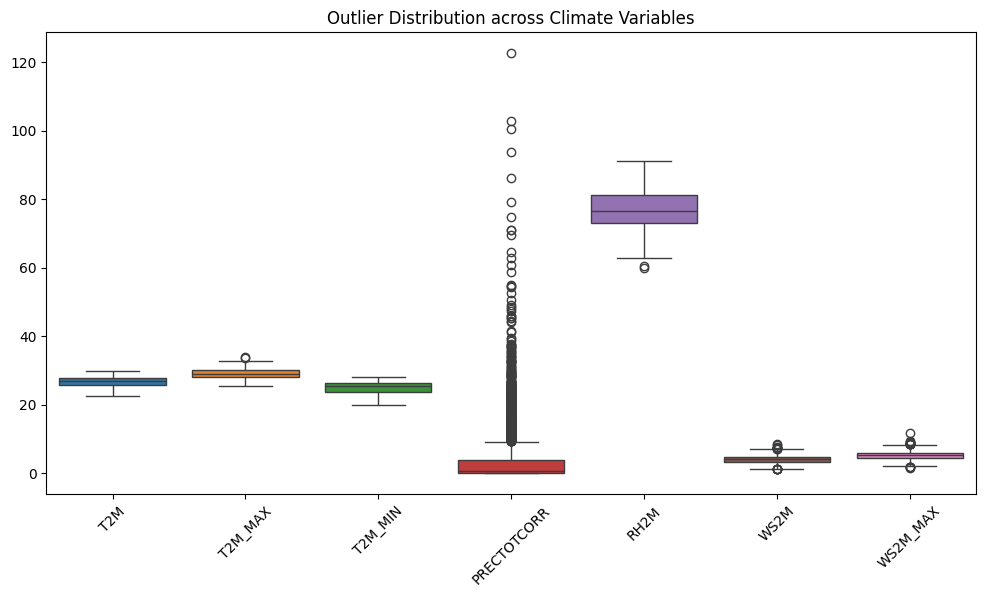

In [116]:
# Visualize outliers using a Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Outlier Distribution across Climate Variables")
plt.xticks(rotation=45)
plt.show()

Identify and drop rows that are mostly empty

In [117]:
missing_threshold = 0.3
mask_extreme_missing = df.isnull().mean(axis=1) > missing_threshold
df_cleaned = df[~mask_extreme_missing].copy()

In [118]:
# 2. Apply Forward Fill (ffill) to handle the remaining small gaps
# This propagates the last valid observation to the next valid one
df_cleaned.ffill(inplace=True)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,3
2026-03-28,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,3
2026-03-29,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,3


In [119]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Total nulls remaining: {df_cleaned.isna().sum().sum()}")

Original shape: (4108, 12)
Cleaned shape: (4108, 12)
Total nulls remaining: 0


In [120]:
output_path = "../data/tanzania_clean.csv"
df_cleaned.to_csv(output_path)

print(f"Success! Cleaned data exported to: {output_path}")

Success! Cleaned data exported to: ../data/tanzania_clean.csv


#### Time Series Analysis

Monthly Temperature Line Chart

In [121]:
# 1. Resample daily data to Monthly Mean (MS = Month Start)
monthly_temp = df_cleaned['T2M'].resample('MS').mean()

In [122]:
# 2. Identify the absolute records for annotation
warmest_val = monthly_temp.max()
warmest_date = monthly_temp.idxmax()

coolest_val = monthly_temp.min()
coolest_date = monthly_temp.idxmin()

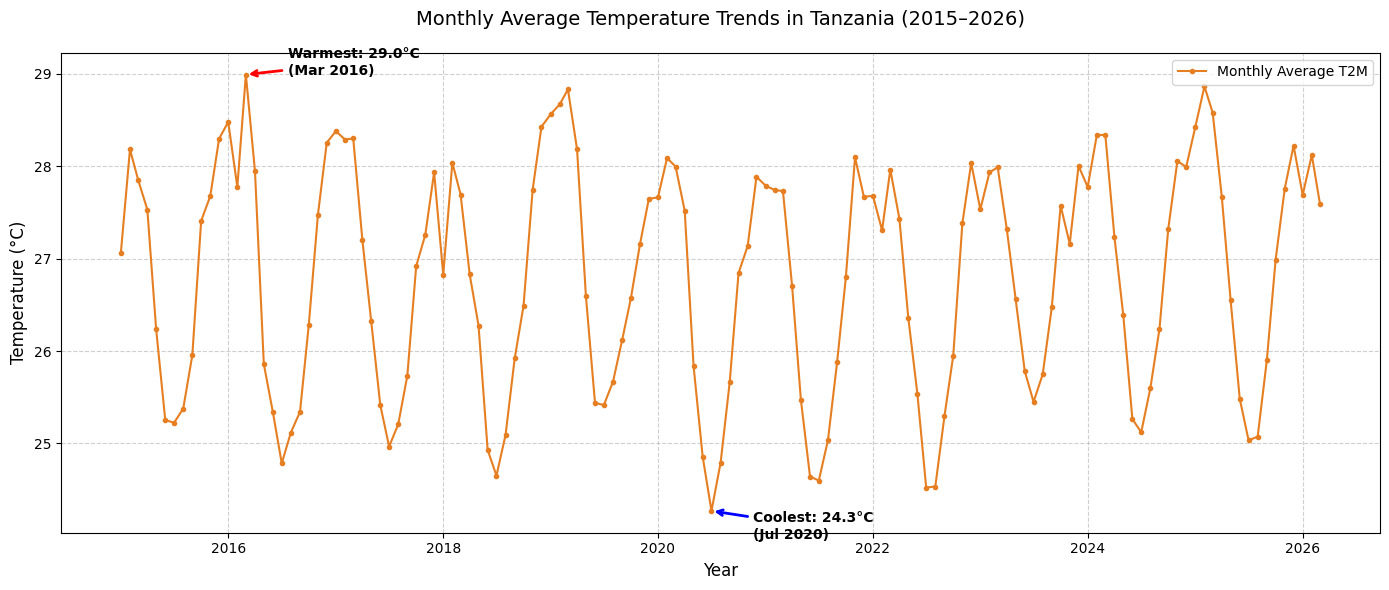

In [123]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp, color='#e67e22', marker='o', markersize=3, linestyle='-', linewidth=1.5, label='Monthly Average T2M')

# 4. Add Annotations for the extremes
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), 
             xytext=(30, 0), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), 
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=10, fontweight='bold')

# 5. Styling
plt.title('Monthly Average Temperature Trends in Tanzania (2015–2026)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of temperature by month

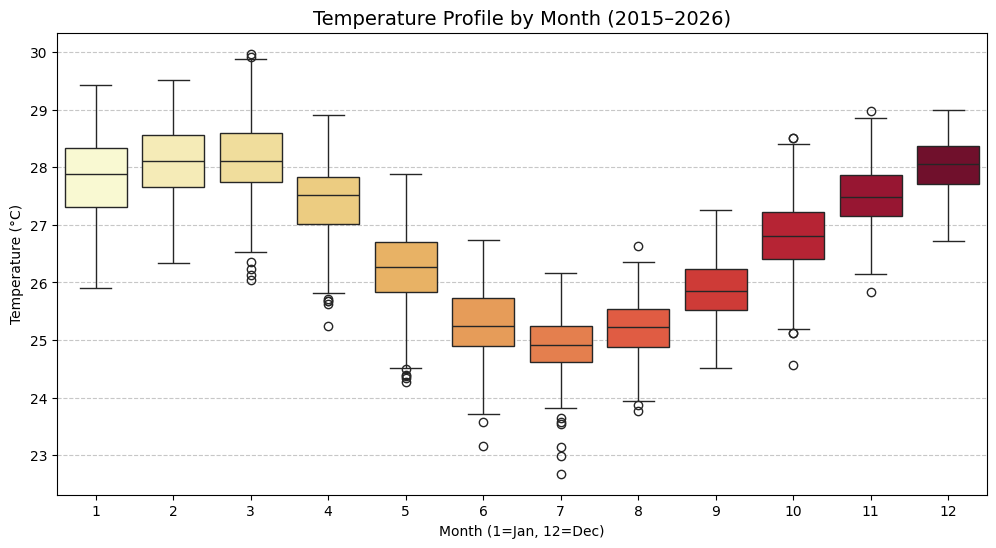

In [124]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='T2M', data=df_cleaned, 
            palette="YlOrRd", hue='Month', legend=False)

# Formatting
plt.title('Temperature Profile by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Monthly Total Precipitation

In [125]:
# 1. Resample daily data to Monthly Total (Sum)
monthly_rain = df_cleaned['PRECTOTCORR'].resample('MS').sum()

In [126]:
# 2. Identify the peak rainy months (e.g., top 3 highest totals)
top_peaks = monthly_rain.nlargest(3)

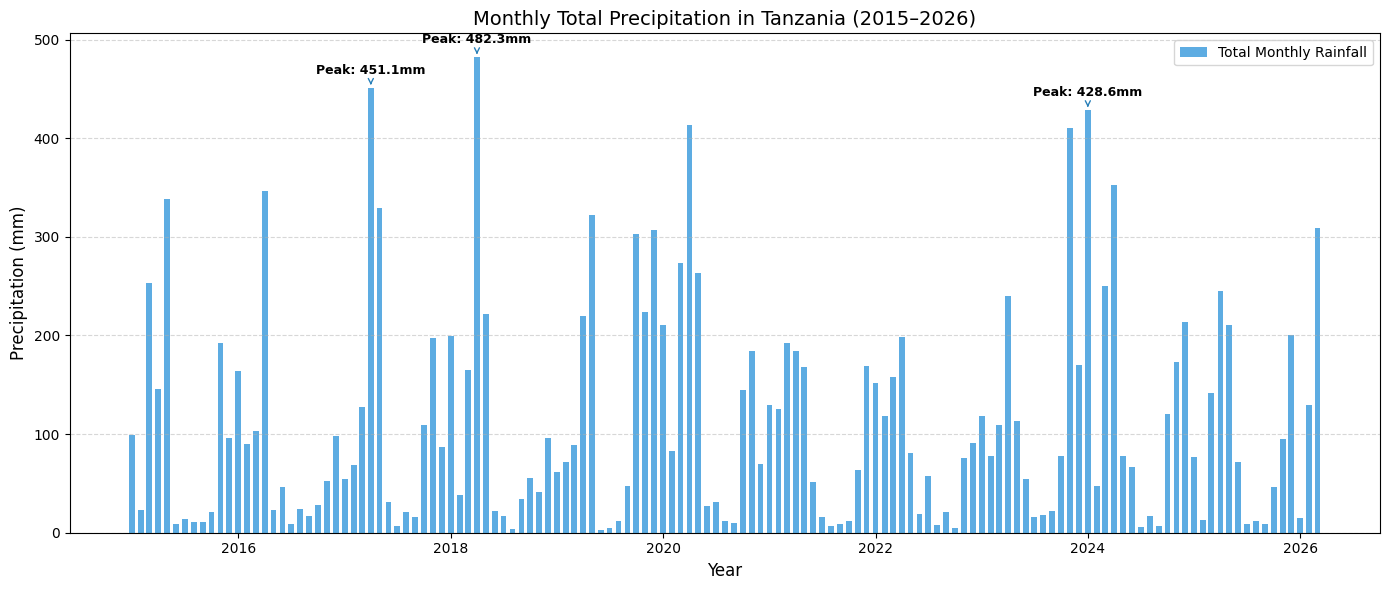

In [127]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain, color='#3498db', width=20, alpha=0.8, label='Total Monthly Rainfall')

# 4. Annotate the peaks
for date, val in top_peaks.items():
    plt.annotate(f'Peak: {val:.1f}mm', 
                 xy=(date, val), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2980b9'))

# 5. Styling
plt.title('Monthly Total Precipitation in Tanzania (2015–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of daily rainfall by month

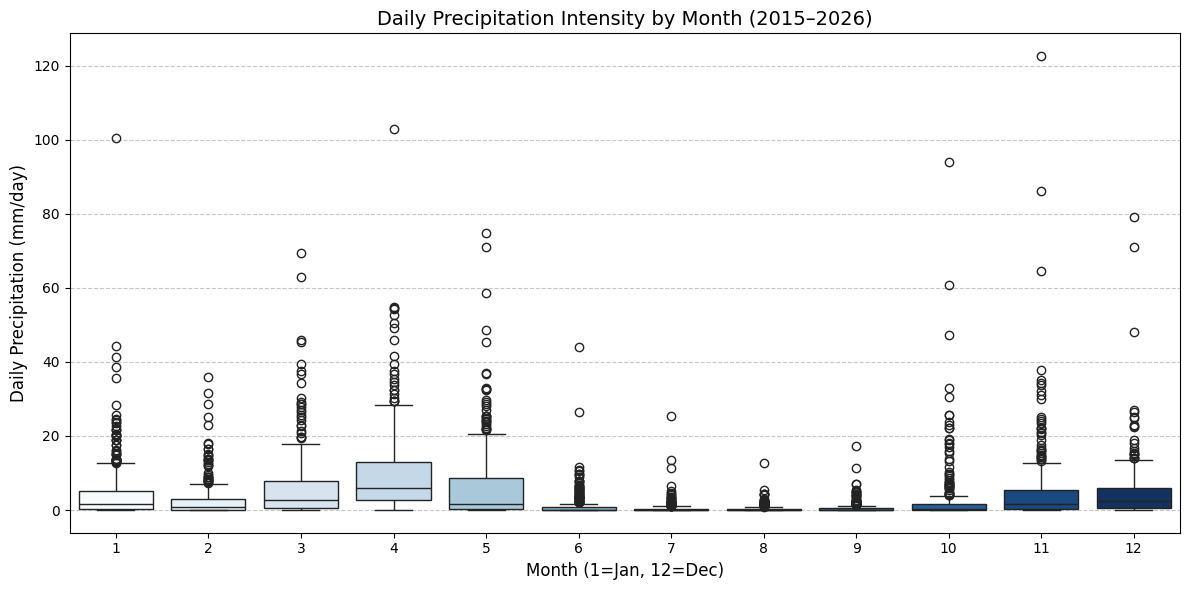

In [128]:
# Create a boxplot to see the distribution of daily rainfall by month
plt.figure(figsize=(12, 6))

# We use a Blue palette to represent water/rainfall
sns.boxplot(x='Month', y='PRECTOTCORR', data=df_cleaned, 
            palette="Blues", hue='Month', legend=False)

# Formatting
plt.title('Daily Precipitation Intensity by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Daily Precipitation (mm/day)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Yearly Average Temperature & Trend Line

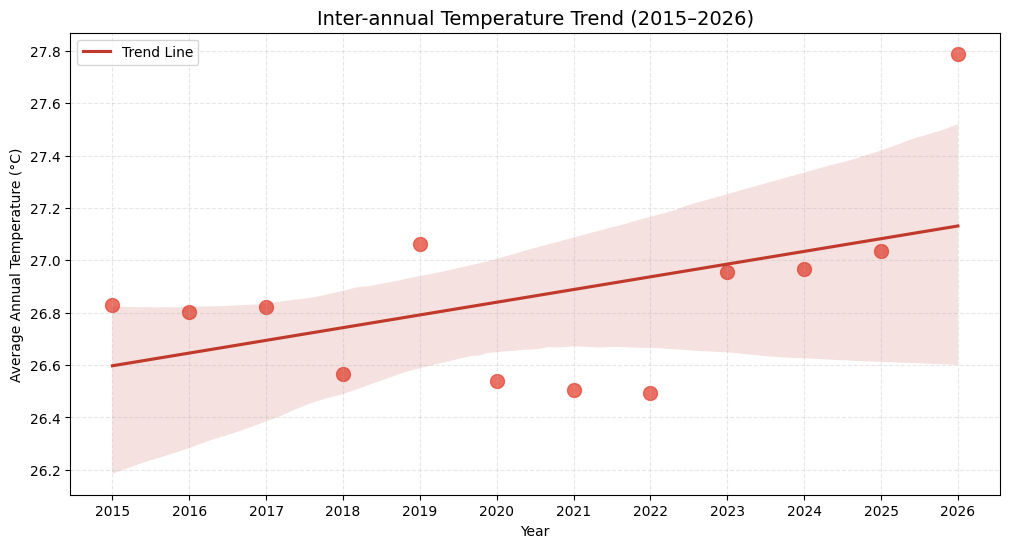

Success! Warming Rate: 0.0485 °C per year


In [129]:
# 1. Resample to get yearly averages
yearly_temp = df_cleaned['T2M'].resample('YE').mean().reset_index()

yearly_temp.columns = ['date', 'T2M']

# 3. Extract Year using the .dt accessor
yearly_temp['Year'] = yearly_temp['date'].dt.year

plt.figure(figsize=(12, 6))

# 4. Plot the Yearly Means and a Regression Line
sns.regplot(data=yearly_temp, x='Year', y='T2M', 
            scatter_kws={'s': 100, 'color': '#e74c3c'}, 
            line_kws={'color': '#c0392b', 'label': 'Trend Line'})

# 5. Labeling and Aesthetics
plt.title('Inter-annual Temperature Trend (2015–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.xticks(yearly_temp['Year']) 
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

# 6. Calculate the Slope (Warming Rate)
slope, intercept, r_value, p_value, std_err = linregress(yearly_temp['Year'], yearly_temp['T2M'])
print(f"Success! Warming Rate: {slope:.4f} °C per year")

#### Correlation & Relationship Analysis

Correlation Heatmap

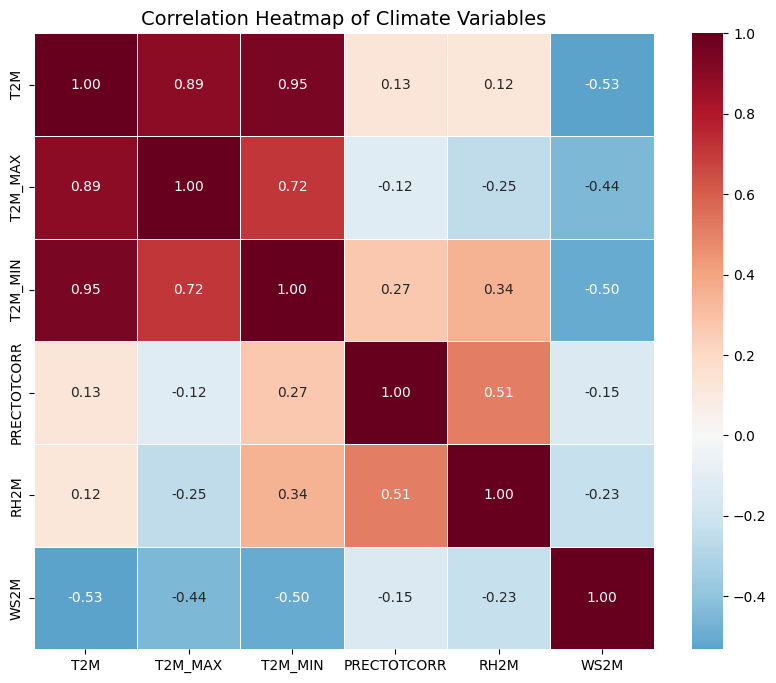

In [130]:
# 1. Calculate the correlation matrix
# We only include numeric columns that represent climate variables
corr_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]
corr_matrix = df_cleaned[corr_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables', fontsize=14)
plt.show()

Scatter Plots

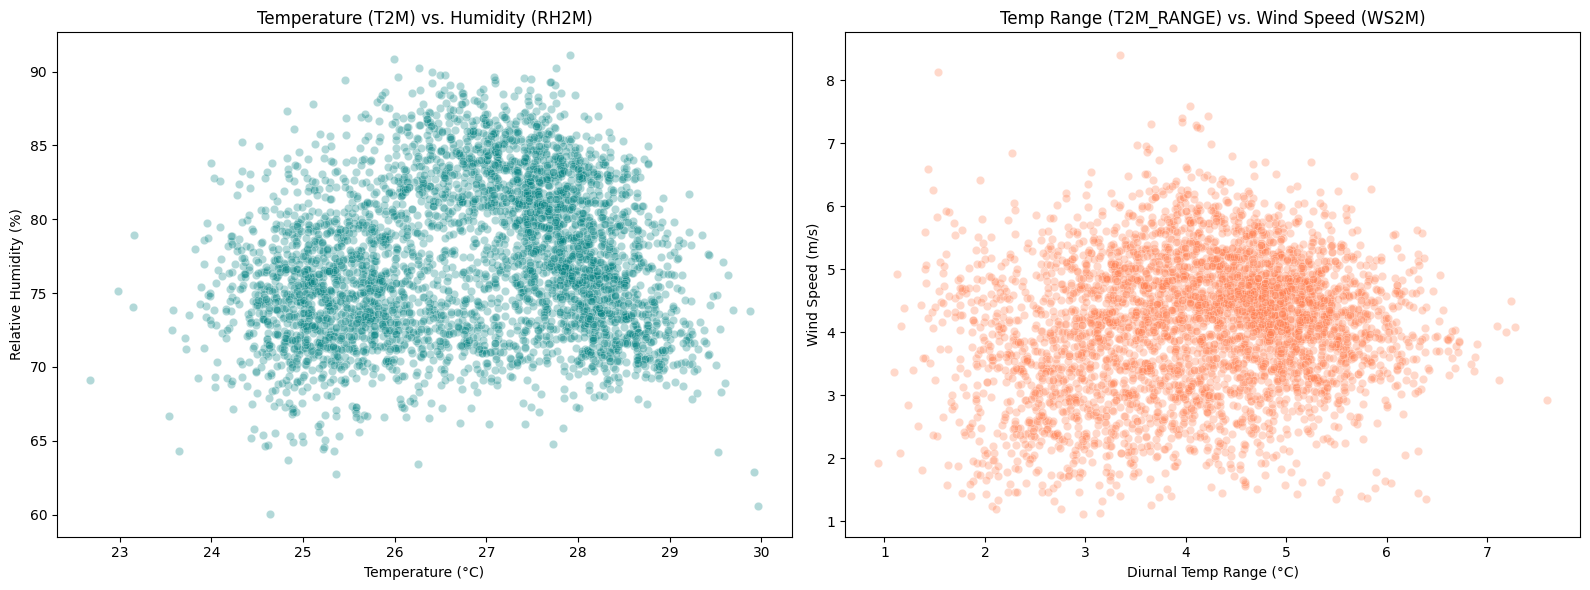

In [131]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Relative Humidity
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('Temperature (T2M) vs. Humidity (RH2M)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed
df_cleaned['T2M_RANGE'] = df_cleaned['T2M_MAX'] - df_cleaned['T2M_MIN']

sns.scatterplot(data=df_cleaned, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('Temp Range (T2M_RANGE) vs. Wind Speed (WS2M)')
ax2.set_xlabel('Diurnal Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

Pair Plot

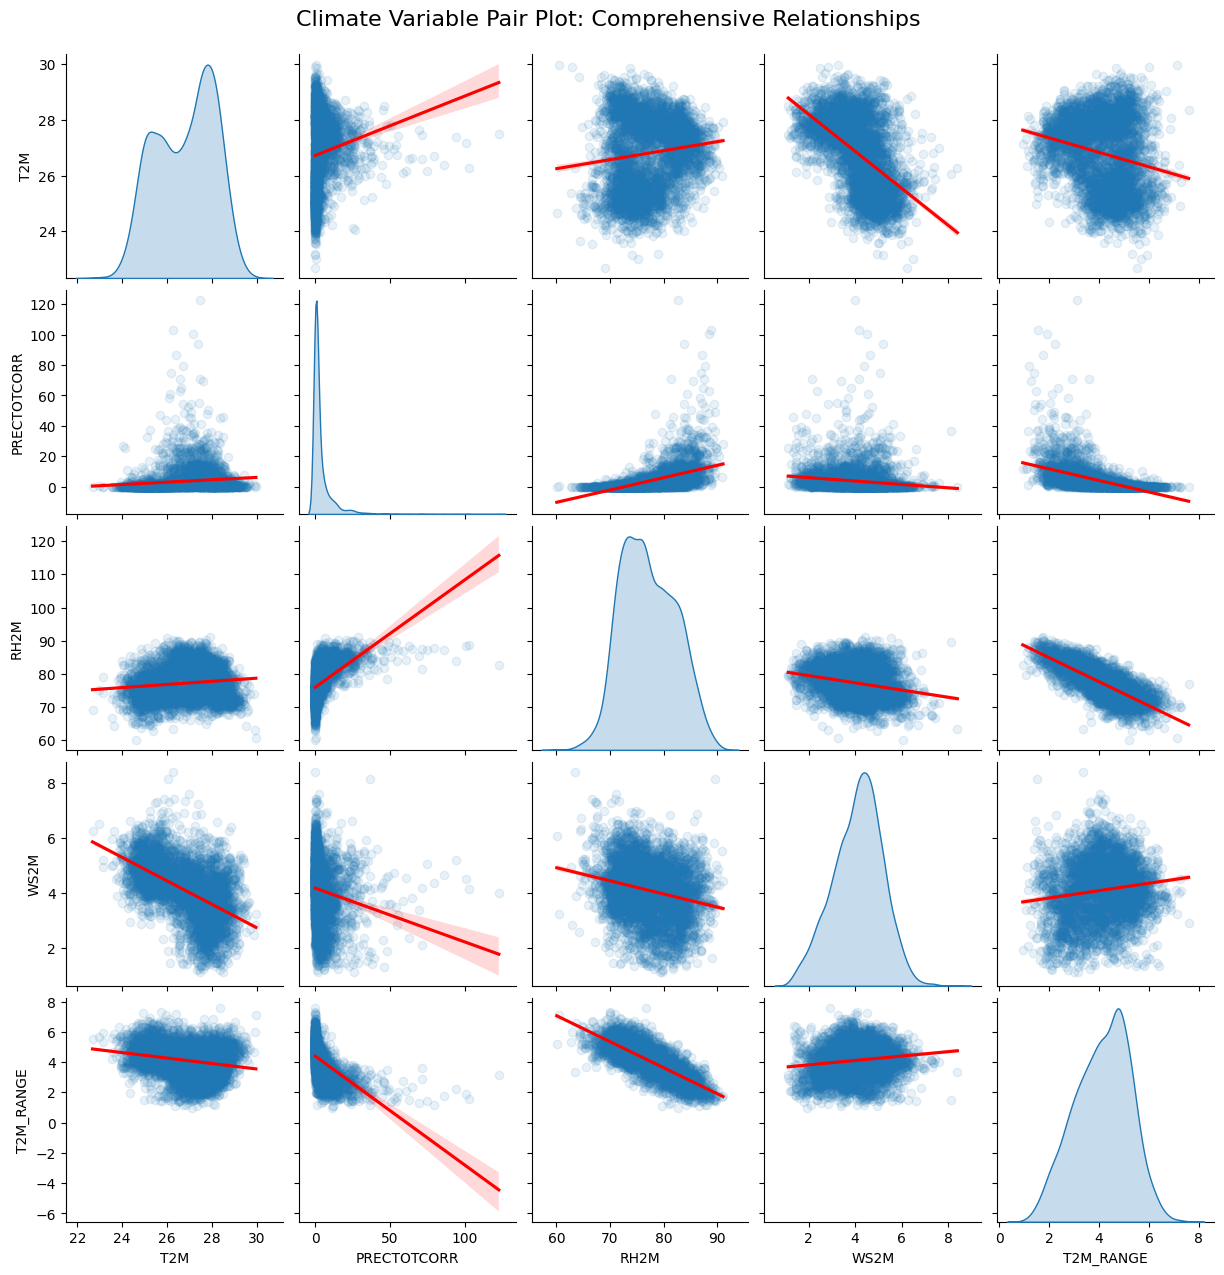

In [132]:
cols = ["T2M", "PRECTOTCORR", "RH2M", "WS2M", "T2M_RANGE"]


grid = sns.pairplot(df_cleaned[cols], 
                    kind='reg', 
                    diag_kind='kde', 
                    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})

grid.fig.suptitle('Climate Variable Pair Plot: Comprehensive Relationships', y=1.02, fontsize=16)
plt.show()

#### Distribution Analysis

In [133]:
skewness = df_cleaned['PRECTOTCORR'].skew()
print(f"Precipitation Skewness: {skewness:.2f}")

Precipitation Skewness: 5.25


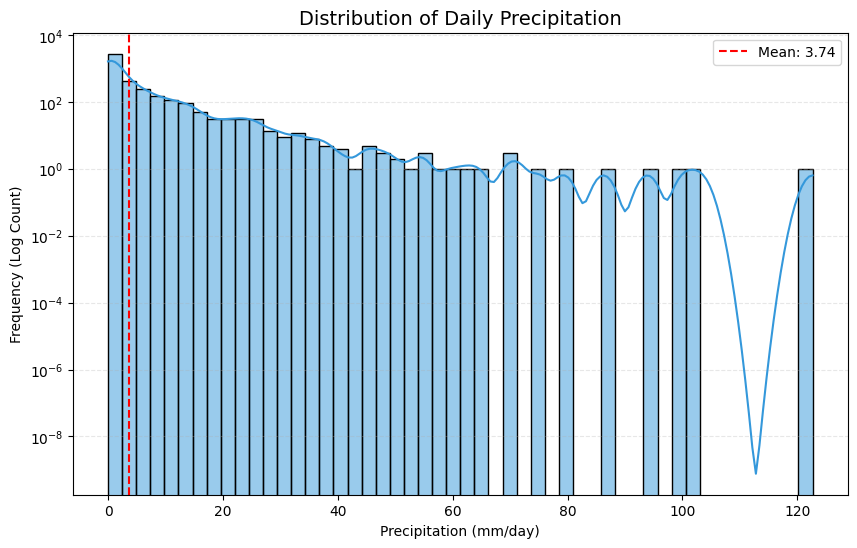

In [134]:
plt.figure(figsize=(10, 6))

# Plotting the histogram
# We keep bins at 50 to see the granularity of the storms
sns.histplot(df_cleaned['PRECTOTCORR'], bins=50, kde=True, color='#3498db')

# Applying the Log Scale because your skewness (3.17) is > 1
plt.yscale('log')

# Adding a vertical line for the mean to show how far the "tail" pulls it
plt.axvline(df_cleaned['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned["PRECTOTCORR"].mean():.2f}')

plt.title('Distribution of Daily Precipitation', fontsize=14)
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

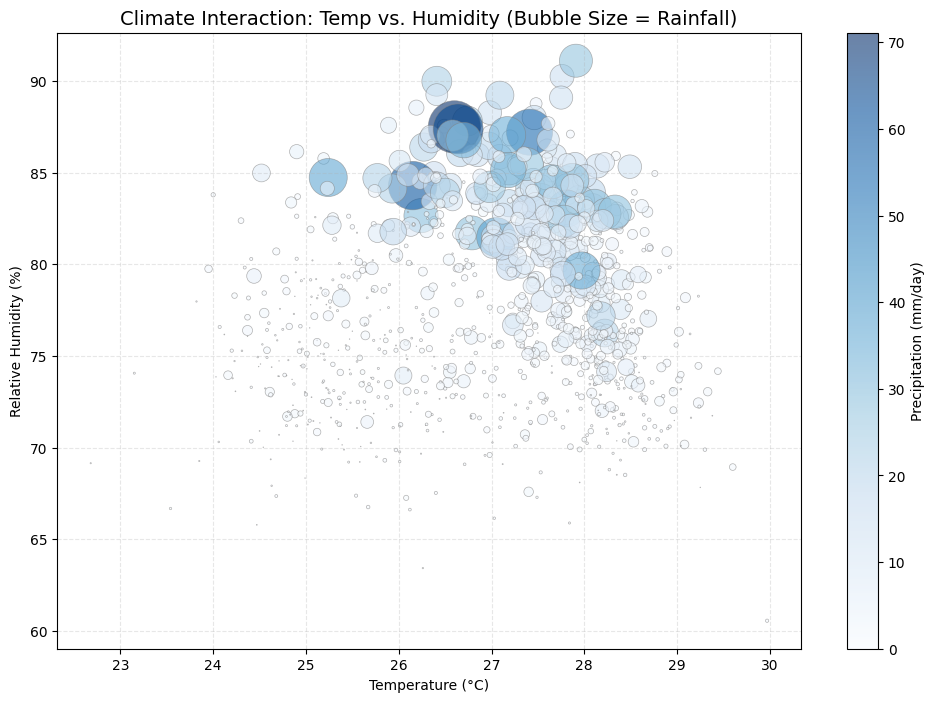

In [96]:
# 1. Take a sample to prevent bubbles from overlapping (1000 points is ideal)
df_sample = df_cleaned.sample(1000, random_state=42)

plt.figure(figsize=(12, 8))

# 2. Create the scatter plot
# s = size (scaled by rainfall), c = color (mapped to rainfall)
scatter = plt.scatter(df_sample['T2M'], 
                      df_sample['RH2M'], 
                      s=df_sample['PRECTOTCORR'] * 20, # Scale factor for visibility
                      c=df_sample['PRECTOTCORR'], 
                      cmap='Blues', 
                      alpha=0.6, 
                      edgecolors='grey', 
                      linewidth=0.5)

# 3. Add a colorbar for context
cbar = plt.colorbar(scatter)
cbar.set_label('Precipitation (mm/day)')

# 4. Final Styling
plt.title('Climate Interaction: Temp vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()